# Поиск инсайтов и точек роста

**Автор:** Кропотов Валентин

**Дата:** 20.02.2026

Конкуренты сервиса не дремлют, и руководство ждёт от продукта роста. Нужно найти инсайты, которые позволят сервису повысить показатель удержания пользователей и улучшить взаимодействие с партнёрами.

Нам необходимо помочь бизнесу ответить на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

В рамках данного проекта мы проведем комплексный анализ данных:
- изучим пользовательский путь и проанализируем конверсии через воронки;
- сегментируем пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризуем рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.

Такой подход позволит ближе познакомиться с работой сервиса, выявить узкие места и предложить решения для удержания пользователей и повышения эффективности сотрудничества с ресторанами.


### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

Загрузим данные и получим первую информацию о них. Проведем необходимую предобработку.

In [1]:
# Обновлять библиотеки мне наверное не стоит, поэтому просто уберем предупреждение
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.fixes")


# Импотируем бибилиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
# Читаем файл
df = pd.read_csv('insides_data.csv', parse_dates=['first_date', 'datetime'])

In [3]:
# Общая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

In [4]:
# Пять случайных строк из датасета
df.sample(5)

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
176002,561c7f53-ffa7-4db4-83e2-6d83a80e48ac,632389.0,Desktop,6,organic,2021-06-19,189520590,main_page,2021-06-20 20:57:09,5b262d151ec1410e94602e422c525c3d,NaN,NaN,NaN,NaN,NaN
154800,0dd335be-2462-451b-a89a-5d930df9c9b9,623108.0,Desktop,1,organic,2021-06-14,186752956,authorization,2021-06-14 15:20:03,NaN,NaN,NaN,NaN,NaN,NaN
146202,b9d9e11d-8402-4373-b45c-82657a59d168,622142.0,Desktop,6,organic,2021-06-13,186463067,login,2021-06-13 22:55:25,NaN,NaN,NaN,NaN,NaN,NaN
134555,a8b1fe28-2e9b-476e-afc1-5cadf1333626,615020.0,Desktop,6,Source_B,2021-06-07,184437461,main_page,2021-06-09 20:28:49,fe285c3040794705afbc17089aafc687,NaN,NaN,NaN,NaN,NaN
128058,36afbd45-70e6-4972-853f-66ae543ad888,69656.0,Desktop,6,organic,2021-06-08,184010235,main_page,2021-06-08 21:51:26,a29747e18d3f4ff487b355d34312aacb,NaN,NaN,NaN,NaN,NaN


In [5]:
# Проверим на дупликаты по сабсету
df.duplicated(subset=['visitor_uuid', 'visit_id', 'datetime']).sum()

0

Дупликатов не обнаружно.

- Проверим совпадают ли индексы строк с пропусками в столбцах с одинаковым количеством пропусков

In [6]:
# Проверим совпадают ли индексы строк с пропусками в столбцах object_id и commission
df['object_id'].isna().index.to_list() == df['commission'].isna().index.to_list()

True

Странно, что поле с коммиссией заполняется уже на этапе просмотра карточек блюд, когда заказ еще не оформлен. Нужно это учесть, если понадобится вычислять выручку.

In [7]:
# Теперь проверим order_id, revenue и delivery
df['order_id'].isna().index.to_list() == df['revenue'].isna().index.to_list() == df['delivery'].isna().index.to_list()

True

Все поля с одинаковым количеством пропусков имеют одинаковую структуру этих самых пропусков, которые обусловлены логикой заполнения базы данных. Т.е. ошибок в данных, скорее всего, нет.

- Посмотрим при каких значениях столбца `event` заполняется поле `rest_id` и не пересекаются ли эти значения

In [8]:
# Список событий с заполненным rest_id
df[~df['rest_id'].isna()]['event'].unique()

array(['main_page', 'object_page', 'add_to_cart', 'order'], dtype=object)

In [9]:
# Список событий с пустым rest_id
df[df['rest_id'].isna()]['event'].unique()

array(['authorization', 'reg_page', 'confirm_phone', 'login'],
      dtype=object)

Поле `rest_id` заполняется при просмотре главной страницы *(почему-то)*, карточки блюда, корзины и заказа. Не очень понятно, почему `rest_id` заполняется при посещении главной страницы приложения. Если бы была возможность, я бы уточнил этот момент, так же как и с заполнением поля с коммиссией для просмотра карточки блюда.

Значения в поле `events` не пересекаются для заполненных и пустых строк в столбце `rest_id`.

- Уникальные значения в категориальных столбцах `device_type` и `source`

In [10]:
print(f'''
Уникальные значения столбца "device_type": {df.device_type.unique()}.

Уникальные значения столбца "source": {df.source.unique()}.
''')


Уникальные значения столбца "device_type": ['Desktop' 'Mobile'].

Уникальные значения столбца "source": ['Source_B' 'organic' 'Source_A' 'Source_C'].



- Проверим есть ли в поле `user_id` значения с не нулевой дробной частью

In [11]:
# Суммируем остаток деления на единицу в столбце user_id
(df['user_id'] % 1).sum()

0.0

В столбце `user_id` нет чисел с не нулевой дробной частью. Значит можно преобразовать его в тип `int`

In [12]:
# Преобразуем float в int
df['user_id'] = df['user_id'].astype(int)

- Диапазон дат

In [13]:
print(f'''
Датасет содержит информацию о пользователях, вперые посетивших продукт в период с {df.first_date.min().date()} по {df.first_date.max().date()}.

А так же информацию о событиях в период с {df.datetime.min().date()} по {df.datetime.max().date()}.
''')


Датасет содержит информацию о пользователях, вперые посетивших продукт в период с 2021-04-30 по 2021-07-01.

А так же информацию о событиях в период с 2021-05-01 по 2021-07-02.



In [14]:
# Еще раз проверяем
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  int32         
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

**Результаты предобработки:**
- В датасете содержится 15 столбцов и 205510 строк
- Дупликатов в данных не обнаружено
- Пропуски в столбцах `rest_id`, `object_id`, `order_id`, `revenue`, `delivery` и `commission` обусловлены логикой их заполнения
- Столбец `user_id` преобразован в тип `int`
- Датасет содержит информацию о пользователях, вперые посетивших продукт в период с `2021-04-30` по `2021-07-01`. А так же информацию о событиях в период с `2021-05-01` по `2021-07-02`.

---

## 2. Анализ пользовательского пути

Маркетологи стали замечать следующее: деньги на рекламу по-прежнему тратятся, а заказов стало меньше. И это несмотря на то, что приложение скачивается и устанавливается так же активно, как раньше. Складывается ощущение, что пользователи где-то теряются. При этом доля заказов с десктопной версии приложения увеличилась по сравнению с мобильной.

Разработчики говорят, что последние обновления мобильной версии приложения не должны были повлиять на каталог блюд или его выбор для заказа и последующей оплаты доставки, так как изменения касались нового алгоритма подтверждения мобильного телефона и адреса доставки.

С помощью воронок изучим общий пользовательский путь новых пользователей, затем сравните поведение пользователей мобильной и десктопной версий приложения. 

**Задача 2.1.** Построим и визуализируем общую воронку (по всем данным), затем опишем пользовательский путь: какие этапы представлены, какова их последовательность, на каком (или на каких) этапах теряется большая часть новых пользователей.
    
При решении построим две воронки: 
- **классическую воронку** — доля от первого шага в процентах
- **step-by-step** — с конверсией от предыдущего этапа.

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [15]:
# Задаем последовательность этапов воронки
funnel_steps = ['authorization', 'main_page', 'reg_page', 'confirm_phone', 'object_page', 'add_to_cart', 'order']

# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа
funnel_steps_df = df[df['event'].isin(funnel_steps)]
funnel_counts = funnel_steps_df.groupby('event')['user_id'].nunique().reindex(funnel_steps)

# Создаем новый датафрейм для воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})

# Считаем классическую и step-by-step конверсии
funnel_df['classic_conversion'] = funnel_df['users'] / funnel_df['users'].iloc[0] * 100
funnel_df['step_by_step'] = funnel_df['users'] / funnel_df['users'].shift(1) * 100

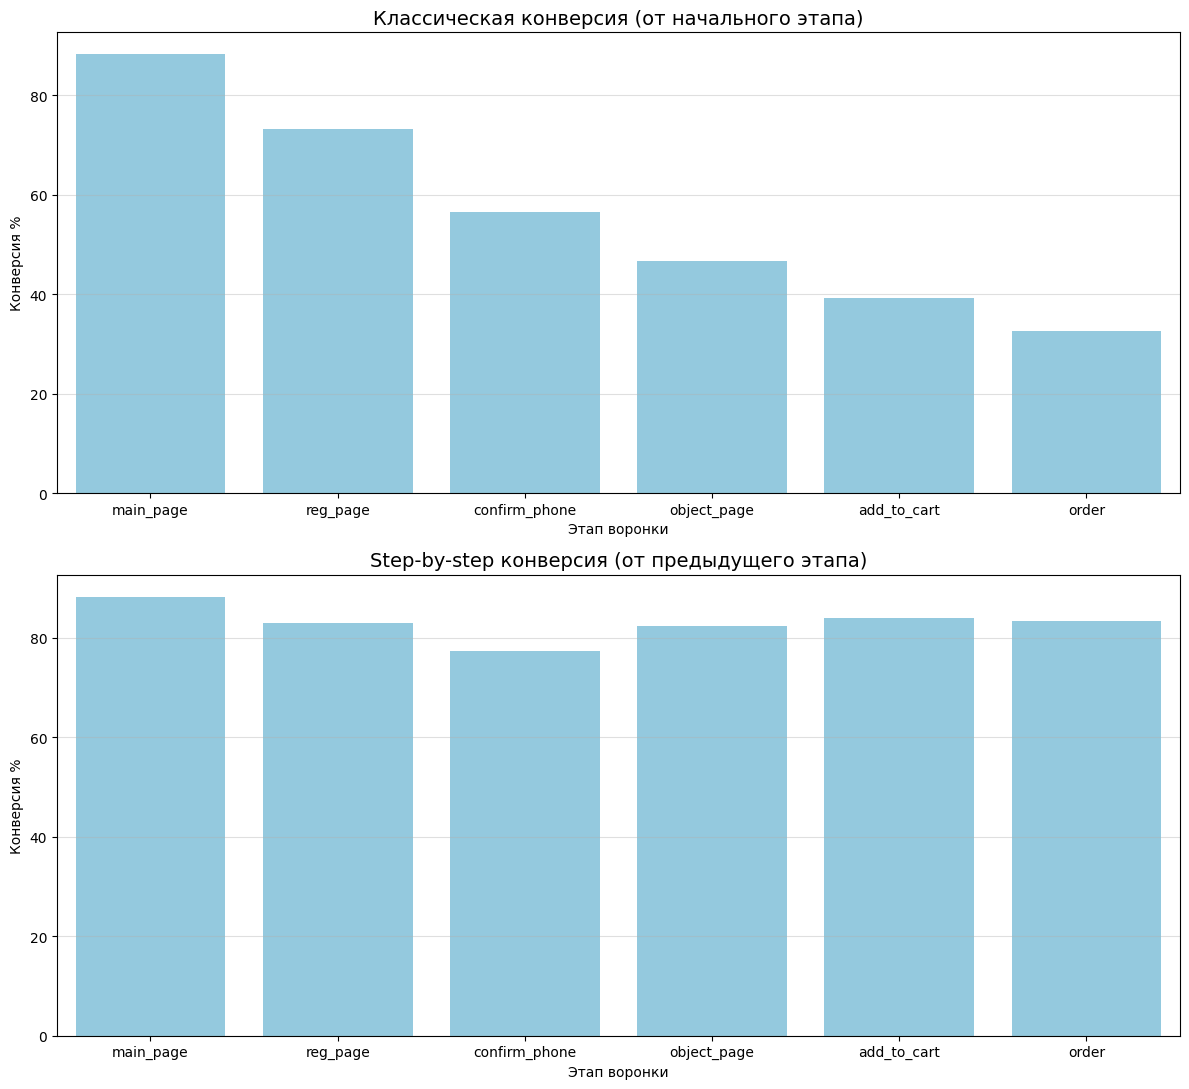

In [16]:
# Создаем два холста
fig, ax = plt.subplots(2, 1, figsize=(12, 11))

# Рисуем графики
sns.barplot(
    data=funnel_df[1:],
    x='step',
    y='classic_conversion',
    ax=ax[0],
    color='skyblue'
)
ax[0].grid(axis='y',alpha=.4)
ax[0].set_title('Классическая конверсия (от начального этапа)', fontsize=14)
ax[0].set_xlabel('Этап воронки')
ax[0].set_ylabel('Конверсия %')

sns.barplot(
    data=funnel_df[1:],
    x='step',
    y='step_by_step',
    ax=ax[1],
    color='skyblue'
)
ax[1].grid(axis='y',alpha=.4)
ax[1].set_title('Step-by-step конверсия (от предыдущего этапа)', fontsize=14)
ax[1].set_xlabel('Этап воронки')
ax[1].set_ylabel('Конверсия %')

plt.tight_layout()
plt.show()

- Из графика `step-by-step конверсии` видно, что больше всего пользователей теряется на этапе подтверждения телефона

**Задача 2.2.** Сравним пользовательский путь в двух приложениях: в мобильной версии и десктопной. Для этого построим и визуализируем **две воронки step-by-step**: для новых пользователей **мобильной** и **десктопной** версий приложения.

In [17]:
# Считаем уникальных пользователей по шагам воронки для мобильной и десктопной версий
desktop_counts = funnel_steps_df[funnel_steps_df['device_type'] == 'Desktop']\
    .groupby('event')['user_id'].nunique().reindex(funnel_steps)

mobile_counts = funnel_steps_df[funnel_steps_df['device_type'] == 'Mobile']\
    .groupby('event')['user_id'].nunique().reindex(funnel_steps)

# Считаем step-by-step конверсию для обоих версий
desktop_funnel = desktop_counts / desktop_counts.shift(1) * 100
mobile_funnel = mobile_counts / mobile_counts.shift(1) * 100

# Объединяем результаты в один датафрейм
funnel_compare = pd.DataFrame({
    'step': funnel_steps[1:],
    'desktop': desktop_funnel[1:].values,
    'mobile': mobile_funnel[1:].values
})

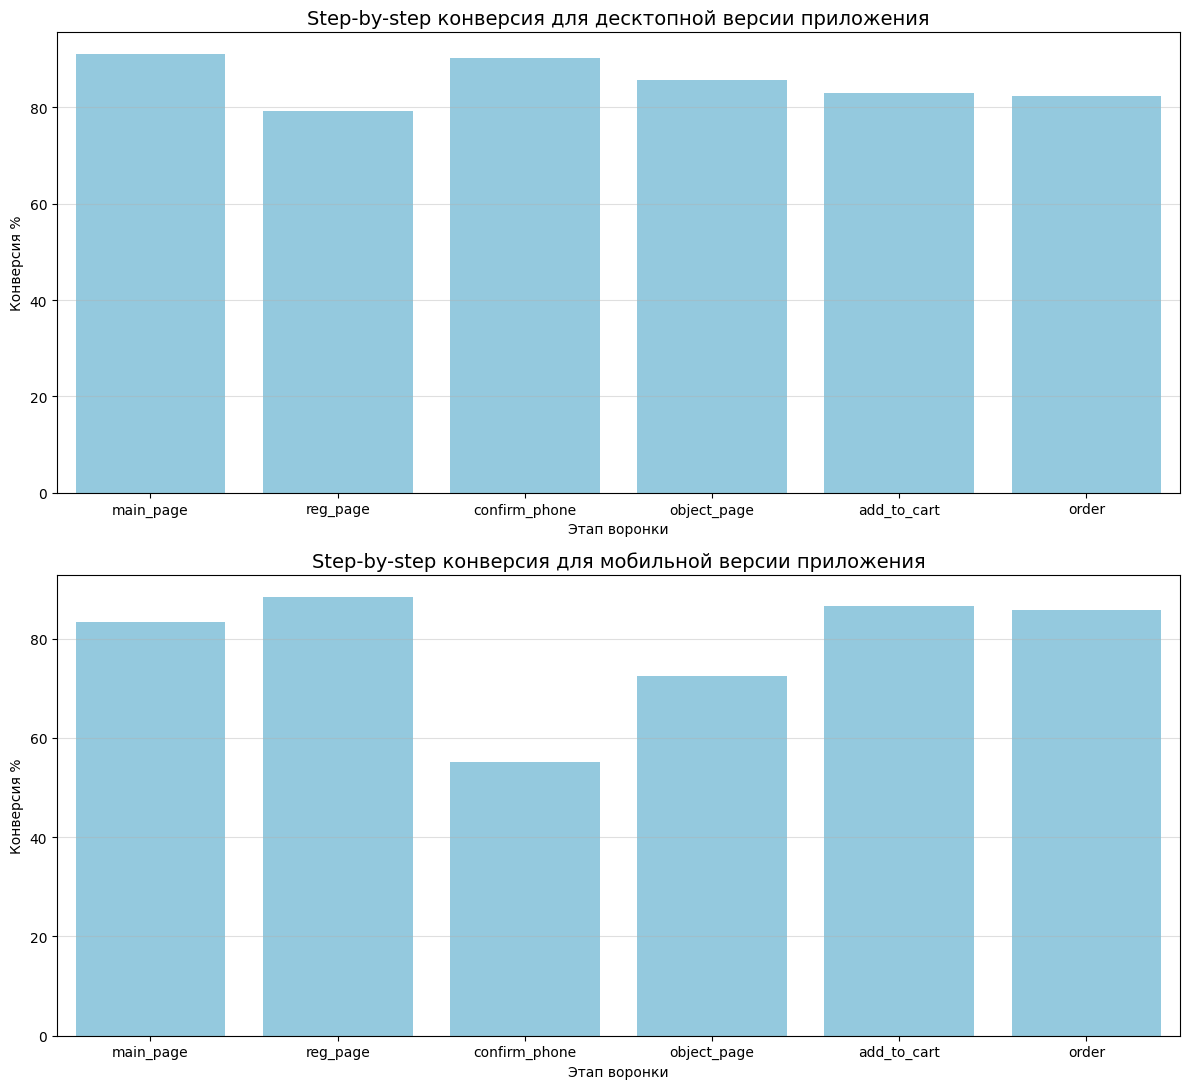

In [18]:
# Создаем два холста
fig, ax = plt.subplots(2, 1, figsize=(12, 11))

# Рисуем графики
sns.barplot(
    data=funnel_compare,
    x='step',
    y='desktop',
    ax=ax[0],
    color='skyblue'
)
ax[0].grid(axis='y',alpha=.4)
ax[0].set_title('Step-by-step конверсия для десктопной версии приложения', fontsize=14)
ax[0].set_xlabel('Этап воронки')
ax[0].set_ylabel('Конверсия %')

sns.barplot(
    data=funnel_compare,
    x='step',
    y='mobile',
    ax=ax[1],
    color='skyblue'
)
ax[1].grid(axis='y',alpha=.4)
ax[1].set_title('Step-by-step конверсия для мобильной версии приложения', fontsize=14)
ax[1].set_xlabel('Этап воронки')
ax[1].set_ylabel('Конверсия %')

plt.tight_layout()
plt.show()

**Выводы:**
- Из графика `step-by-step конверсии` для `десктопной` версии приложения видно, что есть довольно заметный спад количества пользователей при переходе от главной страницы приложения к странице с регистрацией.
- График `step-by-step конверсии` для `мобильной` версии приложения показывает, что только около половины пользователей заканчивают регистрацию. Возможно есть какие-то технические проблемы с подтверждением номера телефона. И далее идет сравнительно низкий показатель конверсии из завершения регистрации к просмотру карточки блюда.

---

## 3. RFM сегментация

У сервиса доставки еды не такое высокое удержание пользователей: в первый день возвращается около 14% посетителей, а на седьмой день и того меньше — около 4–5%. Маркетологи хотят запустить несколько рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы.

Для этого необходимо сегментировать пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

В качестве даты анализа установите **03 июля 2021 года**.

**Задача 3.1.** Для каждого покупателя посчитаем:
- количество дней с последней покупки — давность (R);
- частоту покупок (F);
- стоимость всех покупок — сумму трат (M).

In [19]:
# Оставляем только данные о заказах
orders_df = df[df['event']=='order'].copy()

# Добавляем столбец с количеством дней с последней покупки
orders_df['order_recency'] = pd.to_datetime('2021-07-03') - orders_df['datetime']

# Считаем RFM-показатели
df_rfm = orders_df.groupby('user_id').agg(
    recency = ('order_recency', lambda x: x.min().days),
    frequency = ('event', 'count'),
    monetary_value = ('revenue', 'sum') # считаем сумму трат покупателя, а не коммиссию
).reset_index()

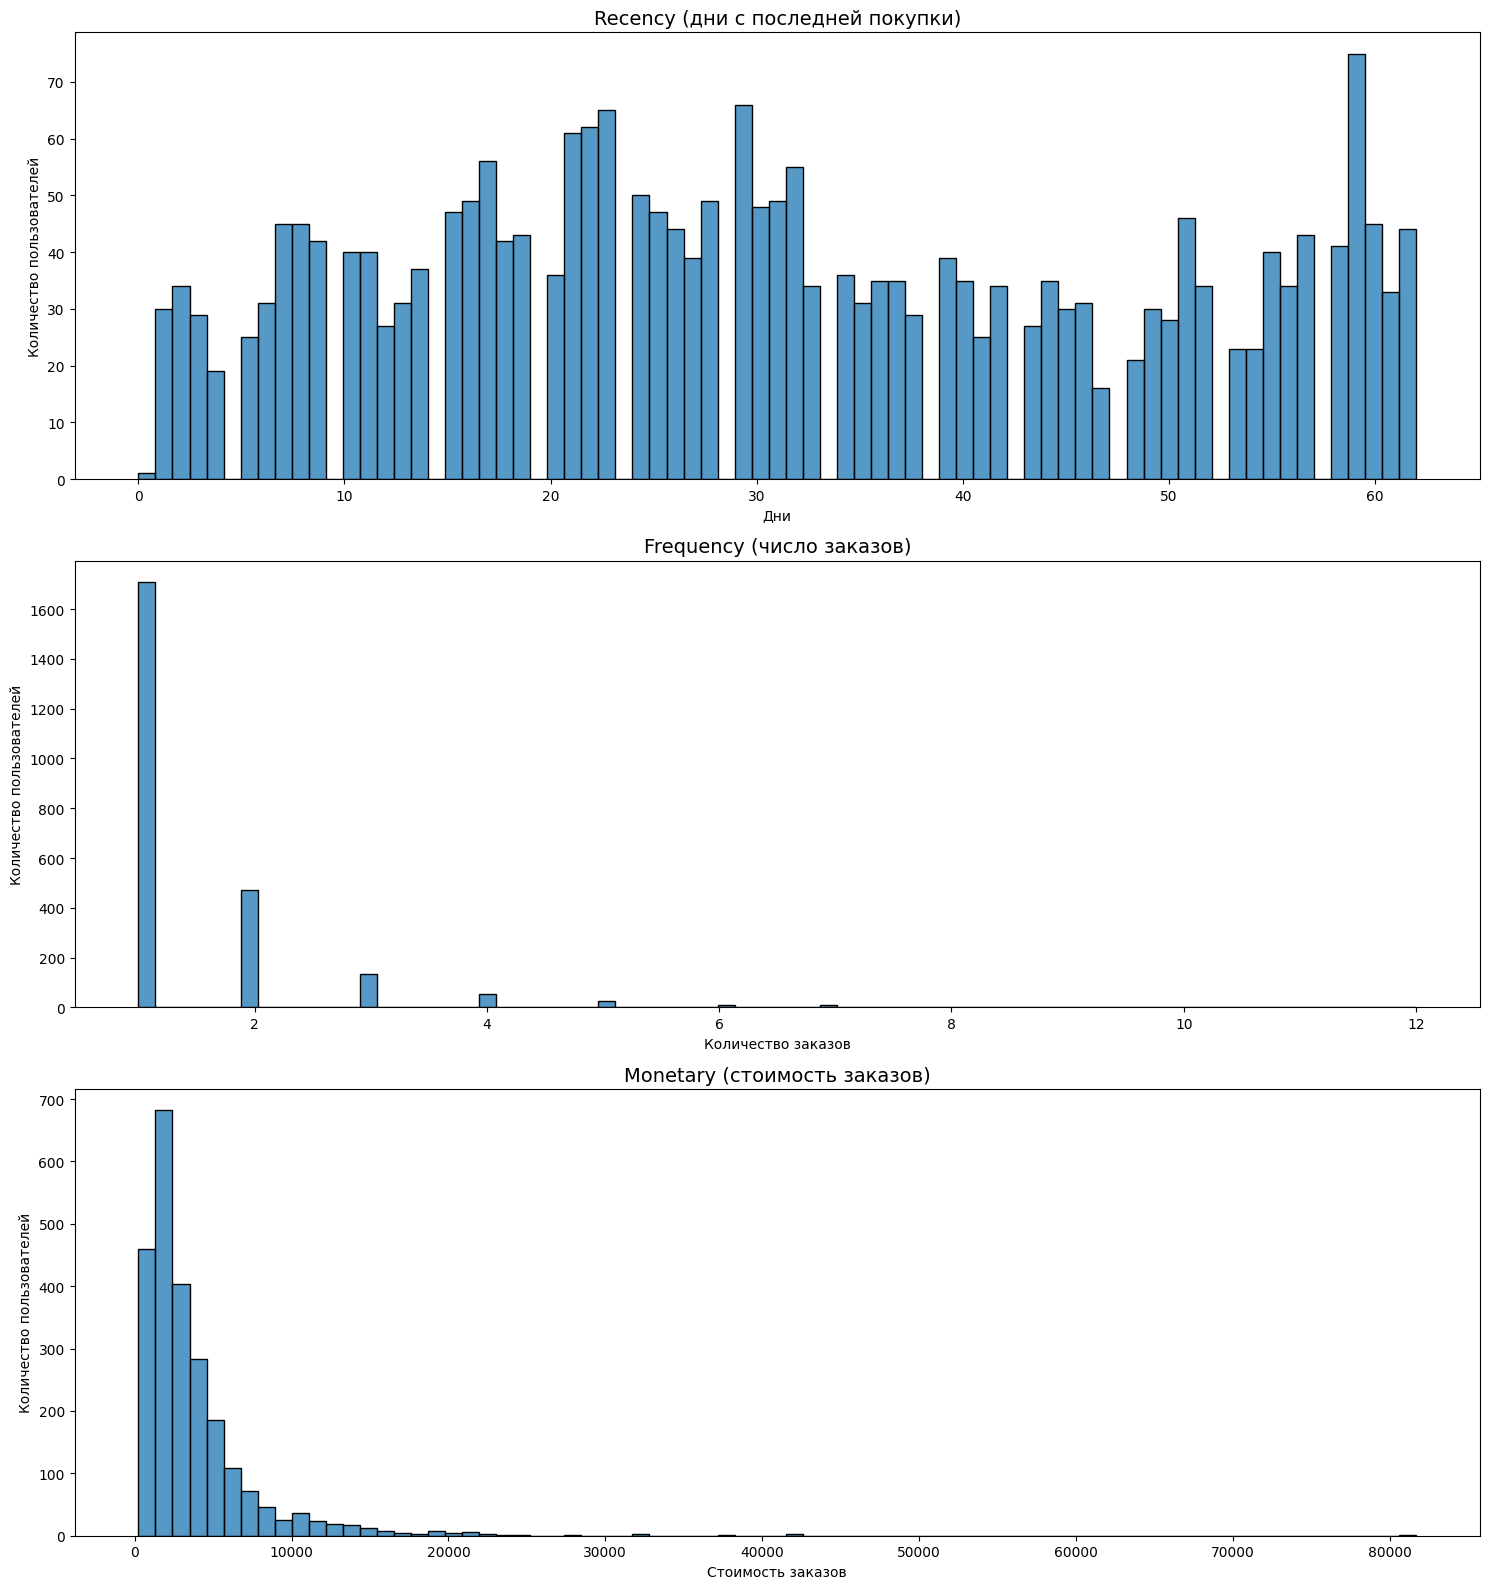

In [20]:
# Рисуем графики
fig, axes = plt.subplots(3, 1, figsize=(15, 16))

sns.histplot(data=df_rfm, x='recency', bins=75, ax=axes[0])
axes[0].set_title('Recency (дни с последней покупки)', fontsize=14)
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

sns.histplot(data=df_rfm, x='frequency', bins=75, ax=axes[1])
axes[1].set_title('Frequency (число заказов)', fontsize=14)
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

sns.histplot(data=df_rfm, x='monetary_value', bins=75, ax=axes[2])
axes[2].set_title('Monetary (стоимость заказов)', fontsize=14)
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

- На гистограмме `recency` видно, что количество дней с последней покупки распределено довольно равномерно. Выделяется период с 15ти до 35ти дней - там пользователей больше всего, а так же около 60ти дней по той же причине.
- Гистограмма `frequency` показывает, что у большинства клиентов один заказ, на втором месте с большим разрывом два заказа. Больше двух заказов есть только у маленького количества пользователей.
- График `monetary` показывает, что у абсолютного большинства пользователей траты не превышают 10 000.

**Задача 3.2.** Выделим **RFM-сегменты** и изучим распределение пользователей по ним.
    
Применим следующие подходы к выделению RFM сегментов:
- **Recency** — разделим на три равные группы.
- **Frequency** —  разделим на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — разделим на три группы по 33-му и 66-му перцентилям.
    
После этого посчитаем количество покупателей в каждом сегменте.

In [21]:
# Разобьем метрики на сегменты
df_rfm['r'] = pd.cut(df_rfm['recency'], bins=3, labels=[3,2,1])
df_rfm['f'] = pd.cut(df_rfm['frequency'], [1, 2, 3, float('inf')], labels=[1,2,3], include_lowest=True)
df_rfm['m'] = pd.qcut(df_rfm['monetary_value'], q=3, labels=[1,2,3])

# Преобразуем значения в строковые и соединим в отдельном столбце
df_rfm[['r', 'f', 'm']] = df_rfm[['r', 'f', 'm']].astype(str)
df_rfm['rfm_group'] = df_rfm['r'] + df_rfm['f'] + df_rfm['m']

# Найдем количество пользователей в каждом сегменте и процент от общего числа пользователей
rfm_group = df_rfm.groupby('rfm_group', as_index=False)['user_id'].nunique()
rfm_group['share'] = (rfm_group['user_id'] / rfm_group['user_id'].sum() * 100).round(2)

# Для удобства чтения таблицы отсортируем данные и добавим столбец с кумулятивной суммой
rfm_group.sort_values(by='user_id', ascending=False, inplace=True)
rfm_group['share_cumsum'] = rfm_group['share'].cumsum()

rfm_group

,rfm_group,user_id,share,share_cumsum
8,212,296,12.25,12.25
7,211,289,11.96,24.21
0,111,263,10.89,35.10
1,112,261,10.80,45.90
15,311,255,10.55,56.45
9,213,237,9.81,66.26
16,312,234,9.69,75.95
17,313,187,7.74,83.69
2,113,160,6.62,90.31
12,223,56,2.32,92.63


**Выводы:**
- 90% пользователей совершили всего один заказ.
- Часть пользователей совершили одну или две покупки недавно и потратили выше 33го перцентиля по общей выборке. Это сегменты `212`, `213`, `312`, `313`, `222`, `322`. Таких клиентов важно стимулировать к повторным покупкам и поддерживать их интерес к продукту.
- Так же есть неактивные клиенты, давно не совершавшие покупок, которых можно попробовать вернуть. К таким относятся сегменты с единицей в начале: `111`, `112`,`113`, `123`, `133`, `122`, `132`.
- Для самых активных клиентов можно разработать персонализированные предложения. Такие клиенты входят в сегменты `223`, `233`, `323`, `333`, `232`, `332`.

---

## 4. K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, маркетологи запросили кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

С помощью метода K-Means разделим рестораны на кластеры, отражающие различные модели работы и целевые сегменты. Это позволяет выделить группы ресторанов с похожими характеристиками и разрабатывать для них эффективные маркетинговые стратегии.

**Задача 4.1.** Подготовим данные для кластеризации и для каждого ресторана подсчитаем:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

In [22]:
# Считаем метрики для каждого ресторана, используя ранее созданный датафрейм с заказами
rest_df = orders_df.groupby('rest_id', as_index=False).agg(
    orders_count = ('event', 'count'),
    avg_revenue = ('revenue', 'mean'),
    unique_objects = ('object_id', 'nunique')
)
rest_df

,rest_id,orders_count,avg_revenue,unique_objects
0,1be5a933aab34fbab594bebba48e976e,144,2260.180222,28
1,1d6bb74687104fa1953924c9684fe624,108,2959.256481,19
2,2c6095730b514c189ee41c65f03febc3,8,1673.000000,4
3,3247a3b5f9494812a3c1a73c5b61f004,33,2777.209697,4
4,39b7eab4f4704ed2886fafe171489960,33,2011.269697,5
5,43e40bacafe8409bb5592877a42d737e,43,3313.064186,6
6,4a693ca500b44ba499f92a724aec5f17,107,2989.588785,12
7,4b9cde3378c447ed81c2c6d4854d4f7e,7,2544.000000,5
8,55d4027ac83e438f9f893892f6903409,1001,2674.652364,75
9,55d6470712ee48e98509478ad6aa18ee,5,4754.400000,2


**Задача 4.2.** Нормализуем данные и найдем оптимальное количество кластеров, использовав метод `.inertia_`. Построим график зависимости инерции от числа кластеров (метод «локтя») и предположим оптимальное количество кластеров.

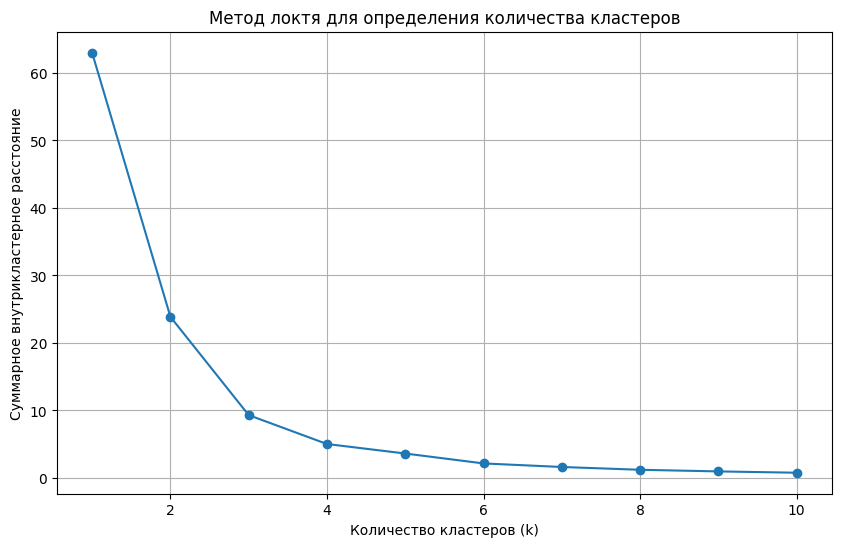

In [23]:
# Импортируем нормализатор для данных
from sklearn.preprocessing import StandardScaler

# Отсавляем в дтатафрейме только метрики
km_df = rest_df.iloc[:,1:]

# Обучаем нормализатор
scaler = StandardScaler()
data_scaled = scaler.fit_transform(km_df)

# Создаем пустой список и набор количества кластеров
i = []
k_range = range(1, 11) # Проверяем от 1 до 10 кластеров

# Перебираем разное количество кластеров
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data_scaled)
    i.append(kmeans.inertia_)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(k_range, i, marker='o')
plt.title('Метод локтя для определения количества кластеров')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Суммарное внутрикластерное расстояние')
plt.grid(True)

- Исходя из получившегося графика я бы сказал, что рестораны будет оптимально поделить на три кластера.

**Задача 4.3.** Проведите кластеризацию, проанализируйте полученные результаты и рассчитайте средние значения по каждому кластеру.
    
После этого визуализируйте результаты, чтобы проследить зависимость признаков друг от друга. Постройте две визуализации, на которые нанесите все кластеры:
- средний чек в зависимости от количества заказов;
- количество блюд в зависимости от количества заказов.

После этого опишите каждый кластер в промежуточном выводе. 

In [24]:
# Обучаем модель на нормализованных данных и добавляем метку кластера дополнительным столбцом в таблицу с метриками по ресторанам
kmeans = KMeans(n_clusters=3, random_state=42) # random_state=42, чтобы после перезапуска ячеек кластеры были под одинаковыми номерами 
km_df['cluster'] = kmeans.fit_predict(data_scaled) + 1 # Чтобы счет кластеров был с 1, а не с 0

# Рассчитываем средние значения признаков для каждого кластера
clusters_df = km_df.groupby('cluster', as_index=False).agg(
    avg_orders = ('orders_count', 'mean'),
    avg_revenue = ('avg_revenue', 'mean'),
    avg_objects = ('unique_objects', 'mean')
).round(2)

clusters_df

,cluster,avg_orders,avg_revenue,avg_objects
0,1,69.60,2167.86,9
1,2,1100.00,2498.83,83
2,3,76.25,4048.50,5


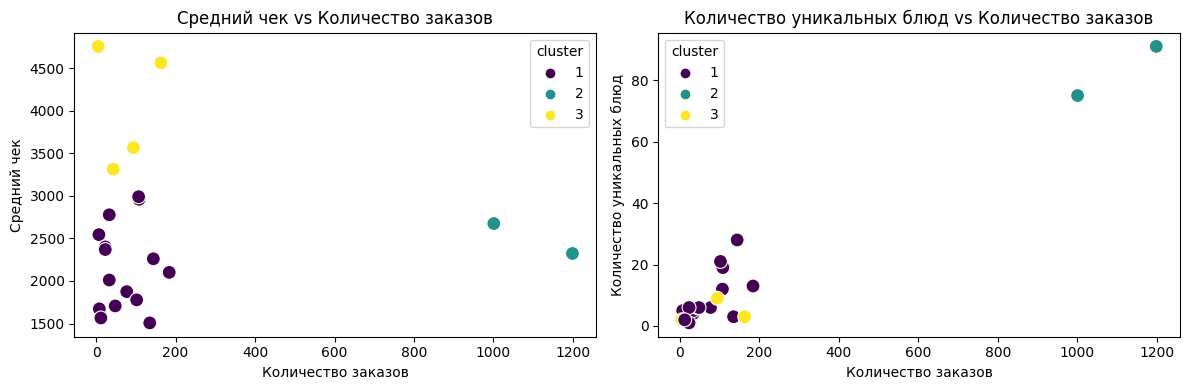

In [25]:
# Рисуем графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Средний чек vs Количество заказов
sns.scatterplot(data=km_df, x='orders_count', y='avg_revenue', 
                hue='cluster', palette='viridis', s=100, ax=axes[0])
axes[0].set_title('Средний чек vs Количество заказов')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Средний чек')

# График 2: Количество уникальных блюд vs Количество заказов
sns.scatterplot(data=km_df, x='orders_count', y='unique_objects', 
                hue='cluster', palette='viridis', s=100, ax=axes[1])
axes[1].set_title('Количество уникальных блюд vs Количество заказов')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество уникальных блюд')

plt.tight_layout()

По всей видимости алгоритм выделил кластеры по следующим принципам:
- **Кластер 1** - середняки. Среднее число заказов (~70) и умеренный средний чек. При этом у них самый широкий ассортимент в своей категории (9 блюд).  Похоже на типичные кафе со средим количеством позиций в меню. 
- **Кластер 2** - сетевые рестораны. Абсолютные лидеры по трафику (1100 заказов), демократичный средний чек и огромный ассортимент (83 блюда). Скорее всего, это крупные сетевые рестораны или очень популярные точки фастфуда с огромным меню.
- **Кластер 3** - нишевые. Заказов столько же, сколько у первого кластера, но средний чек в 2 раза выше (4048 руб.). При этом у них самый маленький ассортимент (всего 5 блюд). Это похоже на солидные рестораны, где меню короткое, но дорогое.

При этом в первом кластере есть растораны с большим количеством блюд (>10), т.е. из него можно выделить еще один кластер, но разделение на 4 кластера сильно картину не меняет. Даже по графикам видно, что количество уникальных блюд как-будто недоучитывается при кластеризации. Может конечно я что-то не понимаю, или нормализацию надо было другую выбрать.

---

## 5. Итоговый вывод и рекомендации

**Общие выводы:**
1. Графики `step-by-step конверсий` для десктопной и мобильной версий приложения показали следующее:
    - В десктопной версии проседает конверсия перехода на страницу регистрации. Может проблемы с интерфейсом, а может это просто нормальная конверсия.
    - В мобильной версии приложения резкая просадка конверсии при подтверждении телефона и затем не очень большое значение конверсии в переход на карточку блюда. Возможно технические проблемы.
2. Необходимо разработать специальные предложения для групп пользоватлей согласно `RFM-сегментации`:
    - Часть пользователей совершили одну или две покупки недавно и потратили выше 33го перцентиля по общей выборке. Это сегменты `212`, `213`, `312`, `313`, `222`, `322`. Таких клиентов важно стимулировать к повторным покупкам и поддерживать их интерес к продукту.
    - Так же есть неактивные клиенты, давно не совершавшие покупок, которых можно попробовать вернуть. К таким относятся сегменты с единицей в начале: `111`, `112`,`113`, `123`, `133`, `122`, `132`.
    - Для самых активных клиентов можно разработать персонализированные предложения. Такие клиенты входят в сегменты `223`, `233`, `323`, `333`, `232`, `332`.
4. При `K-Means кластеризации` было выделено 3 кластера:
    - `Кластер 1` - есть потенциал для роста. Это самая массовая группа стоит предложить им маркетинговые инструменты (акции, подборки, сеты), чтобы увеличить количество заказов, используя их широкий ассортимент(хотя он там не у всех такой).
    - `Кластер 2` - супер успешный. Нужно изучить их опыт: почему у них так много заказов? Может, у них лучше оформлены карточки блюд или быстрее работает доставка?
    - `Кластер 3` - нишевый-сегмент. Количество заказов у них с Кластером 1 схожее, но аудитория совершенно разная. С ними лучше работать над имиджевой рекламой и качеством фотографий блюд, так как каждый заказ здесь стоит дорого. А так же работать над возвращаемостью клиентов, а не на массовый трафик.